# Monotonicity-signature faithfulness scores for NL→FOL translations: demo

This notebook demos **Arm A** of the iter-1 NL→FOL faithfulness screen. The metrics need **no gold formula**. Each one takes a
sentence and a candidate first-order-logic (FOL) formula and predicts whether the formula is *faithful* to the sentence.

**How the metric works** (`signature_faithfulness(text, fol, variant)`):
* **Text side:** every content word of the sentence gets a *polarity*. It is upward-entailing (`+`) in a scope or consequent position, and downward-entailing (`-`) in a restrictor, antecedent or negated position.
  Variant **A3** (zero-LLM) gets the polarity from a rule-based monotonicity calculus over a spaCy parse. Variants **A1/A2** ask an LLM substitution-entailment questions instead.
* **Formula side:** for each predicate `P`, the pipeline checks with **z3** whether the formula is upward or downward monotone in `P` over *all* finite models of size 1..3, using an exact SAT check on a grounding.
* A lexical aligner maps formula predicates to text concepts. The score is `1 - weighted fraction of mismatching coordinates`. The coordinates are polarity mismatches, dropped concepts, added or vacuous predicates, swapped role arguments and relativized coordination.
  The metric also returns a **predicted error type**.
* Controls: **A0** scores alignment only (no polarity), and **Ccov** is concept coverage.

**Full-run headline** (835 real Logic-LM candidates, labels from blind bijection-equivalence to the corrected FOLIO gold):
A1 AUROC 0.711 [0.663, 0.756], A3 0.718 [0.673, 0.763], B1 Gemini judge 0.644, B4 decomposed LLM judge 0.715 and B5 oracle 0.741.
The pre-registered verdict was **no survivor**: every candidate failed the rewrite false-alarm gate (13–14%), and all of those false alarms came from synonym-renamed rewrites.
Every metric is near chance in the top complexity tercile.

**What this demo does:** it writes the original source modules to `src/` unchanged and defines the original `method.py` API. It runs the built-in `--demo` examples, then **re-scores a stratified subset of 100 real candidates** with the zero-LLM variants (A3, A0, Ccov).
It compares the recomputed scores with the stored full-run scores, and puts them next to the stored LLM-based baselines (A1, B1, B3, B4, …).

## Setup
The install cell follows the Colab pattern. Packages that Colab already ships are installed (at Colab's versions) only when running outside Colab.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Pre-installed on Colab (numpy, scipy, sklearn, matplotlib, nltk, spacy, torch, transformers, sentence-transformers):
# install locally only, at Colab's versions
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0',
         'nltk==3.9.1', 'spacy==3.8.11', 'tqdm==4.67.3', 'Pillow==11.3.0', 'requests==2.32.4')
    _pip('torch==2.9.0', '--index-url', 'https://download.pytorch.org/whl/cpu')
    _pip('transformers==5.0.0', 'tokenizers==0.22.2', 'huggingface_hub==1.4.0')
    _pip('--no-deps', 'sentence-transformers==5.2.0')

# NOT on Colab: always install (z3 SAT solver, loguru logging, spaCy English model)
_pip('z3-solver==5.1.0.0', 'loguru==0.7.3')
_pip('--no-deps', 'https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports
The first block is the original `method.py` import block. The notebook adds its own extras below it: plotting, AUROC, and the NLTK WordNet data that the aligner's lemmatizer needs.

In [2]:
from __future__ import annotations

import argparse
import asyncio
import subprocess
import sys
from pathlib import Path

from loguru import logger

# --- notebook additions ---
import json, time, collections
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import nltk
nltk.download("wordnet", quiet=True); nltk.download("omw-1.4", quiet=True)  # used by align.py (WordNetLemmatizer)
Path("src").mkdir(exist_ok=True)   # the %%writefile cells below write the original source modules here

## Data loading
`mini_demo_data.json` holds 100 real Logic-LM candidates (gpt-3.5-turbo, gpt-4, text-davinci-003) for FOLIO-dev sentences. They are stratified by system × complexity tercile × label. Each has its blind equivalence label, and the stored full-run scores of every metric and baseline. The file also carries the full-run AUROC table.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-abf543-do-sentence-and-formula-generalize-the/main/round-1/experiment-1/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            d = json.loads(response.read().decode())
            if "examples" in d: return d  # ignore a stale file with a different schema
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
examples = data["examples"]
print(len(examples), "examples from", data["source_dataset"])
print(collections.Counter((e["system"], e["label"]) for e in examples))
print(json.dumps(examples[0], ensure_ascii=False, indent=1)[:1200])

100 examples from folio_logiclm_screen_real
Counter({('gpt-3.5-turbo', 0): 19, ('gpt-3.5-turbo', 1): 18, ('text-davinci-003', 0): 17, ('gpt-4', 1): 16, ('gpt-4', 0): 15, ('text-davinci-003', 1): 15})
{
 "item_id": "312bdd0032:gpt-3.5-turbo",
 "sentence": "If someone is from Mars, then they are aliens.",
 "fol": "∀x (FromMars(x) → Alien(x))",
 "label": 1,
 "output": "faithful(equiv)",
 "system": "gpt-3.5-turbo",
 "tercile": "mid",
 "parse_ok": true,
 "gold_fol": "∀x (FromMars(x) → Alien(x))",
 "gold_source": "original",
 "stored_scores": {
  "A1": 1.0,
  "A2": 1.0,
  "A3": 1.0,
  "B1": 1.0,
  "B2": 1.0,
  "B2sat": 1.0,
  "B3cos": 0.0791,
  "B3nli": 0.0071,
  "B4": 1.0,
  "B5": 1.0,
  "B5A2": 1.0,
  "B7": 1.0,
  "B8": 1.0,
  "A0": 1.0,
  "Ccov": 1.0
 },
 "stored_error_type_pred_A3": "none",
 "stored_error_type_pred_A1": "none"
}


## Configuration
These are all the tunable knobs of the demo. The solver bound `N=3` and timeout `5000 ms` stay hard-coded inside `signature_faithfulness`, as in the original.

In [5]:
N_EXAMPLES = 100          # how many of the 100 mini examples to re-score (the original screen scored all 835 real candidates)
VARIANTS = ["A3", "A0", "Ccov"]   # zero-LLM variants recomputed here. A1/A2 need an LLM (OPENROUTER_API_KEY, ~$0.0025/sentence)
RUN_LLM_VARIANTS = False  # set True (with OPENROUTER_API_KEY set) to also recompute A1 via google/gemini-2.5-flash
if RUN_LLM_VARIANTS:
    import nest_asyncio; nest_asyncio.apply()  # notebook: lets method.py's asyncio.run() work inside Jupyter's event loop
    VARIANTS = VARIANTS + ["A1"]

## Source modules (original `src/`, copied unchanged)
`method.py` imports its building blocks from `src/`. Each cell below writes one original module to disk as-is.

### `src/fol_parse.py`: FOL parser
This parses FOLIO / Logic-LM Unicode FOL syntax into a hashable tuple AST. Unparseable outputs raise `ParseError`. The metric then returns *uncovered* (score 0.5), and the item is counted, never dropped.

In [6]:
%%writefile src/fol_parse.py
"""FOLIO-syntax FOL parser -> hashable tuple AST, printer, and AST utilities.

Grammar (Unicode, FOLIO / Logic-LM style):
  quantifiers ∀x ∃x (variables: any identifier bound by a quantifier)
  connectives ¬ ∧ ∨ → ↔ ⊕ with precedence ¬ > ∧ > ∨ > → > ↔,⊕ ; → is right-associative
  atoms Name(t1, ..., tk), zero-arity atoms Name, equalities t1 = t2, t1 ≠ t2
  terms: identifiers only (constants may contain digits/underscores/unicode letters); no function terms.
Anything else (∈, ⊆, ≤, '::', ForAll(, LaTeX, nested function terms) raises ParseError.

Quantifier scope: if the quantifier is followed by '(' the scope is that parenthesised group
(FOLIO convention); otherwise (∀x Dog(x) → Bark(x)) the scope extends as far right as possible.
Unbound single-letter lowercase arguments (x, y, z, x1 ...) are treated as FREE VARIABLES and
universally closed (flag free_vars=True). All other unbound arguments are constants.

AST node forms (tuples, hashable):
  ('atom', name, (term, ...))  term = ('v', name) | ('c', name)
  ('eq', t1, t2)
  ('not', f)
  ('and', (f1, f2, ...)) / ('or', (f1, f2, ...))   n-ary, flattened
  ('imp', a, b) / ('iff', a, b) / ('xor', a, b)
  ('all', var, f) / ('ex', var, f)
"""
from __future__ import annotations

import re
from dataclasses import dataclass, field

TOKEN_RE = re.compile(r"\s*(∀|∃|¬|∧|∨|→|↔|⊕|≠|=|\(|\)|,|\w+|\S)", re.U)
BINOPS = {"↔": (1, "iff"), "⊕": (1, "xor"), "→": (2, "imp"), "∨": (3, "or"), "∧": (4, "and")}
FREE_VAR_RE = re.compile(r"^[a-z]\d*$")


class ParseError(ValueError):
    pass


def tokenize(s: str) -> list[str]:
    s = s.strip()
    toks, pos = [], 0
    while pos < len(s):
        m = TOKEN_RE.match(s, pos)
        if not m:
            break
        toks.append(m.group(1))
        pos = m.end()
        while pos < len(s) and s[pos].isspace():
            pos += 1
    for t in toks:
        if not (t in "∀∃¬∧∨→↔⊕≠=(),") and not re.fullmatch(r"\w+", t, re.U):
            raise ParseError(f"unsupported symbol {t!r}")
    return toks


@dataclass
class Parsed:
    ast: tuple
    free_vars: bool = False
    preds: dict = field(default_factory=dict)   # name -> arity
    consts: list = field(default_factory=list)  # sorted constant names
    arity_conflict: bool = False


class _Parser:
    def __init__(self, toks: list[str]):
        self.t, self.i = toks, 0
        self.bound: list[str] = []
        self.free: set[str] = set()

    def peek(self):
        return self.t[self.i] if self.i < len(self.t) else None

    def eat(self, x=None):
        tok = self.peek()
        if tok is None:
            raise ParseError("unexpected end")
        if x is not None and tok != x:
            raise ParseError(f"expected {x!r} got {tok!r}")
        self.i += 1
        return tok

    def parse(self, minp: int = 1):
        lhs = self.unary()
        while self.peek() in BINOPS and BINOPS[self.peek()][0] >= minp:
            op = self.eat()
            p, name = BINOPS[op]
            rhs = self.parse(p if name == "imp" else p + 1)
            if name in ("and", "or"):
                parts = []
                for x in (lhs, rhs):
                    parts.extend(x[1] if x[0] == name else (x,))
                lhs = (name, tuple(parts))
            else:
                lhs = (name, lhs, rhs)
        return lhs

    def unary(self):
        tok = self.peek()
        if tok in ("∀", "∃"):
            self.eat()
            v = self.eat()
            if not re.fullmatch(r"\w+", v, re.U):
                raise ParseError(f"bad variable {v!r}")
            self.bound.append(v)
            try:
                if self.peek() == "(":
                    body = self.group()
                elif self.peek() in ("∀", "∃", "¬"):
                    body = self.unary()
                    # allow ∀x ∀y A(x) → B(y): if an operator follows, widen scope
                    while self.peek() in BINOPS:
                        op = self.eat()
                        _, name = BINOPS[op]
                        rhs = self.parse(1)
                        body = (name, body, rhs) if name not in ("and", "or") else (name, (body, rhs))
                else:
                    body = self.parse(1)  # wide scope
            finally:
                self.bound.pop()
            return ("all" if tok == "∀" else "ex", v, body)
        if tok == "¬":
            self.eat()
            return ("not", self.unary())
        if tok == "(":
            return self.group()
        return self.atom()

    def group(self):
        self.eat("(")
        n = self.parse()
        self.eat(")")
        return n

    def term(self, name: str):
        if not re.fullmatch(r"\w+", name, re.U):
            raise ParseError(f"bad term {name!r}")
        if name in self.bound:
            return ("v", name)
        if FREE_VAR_RE.match(name):
            self.free.add(name)
            return ("v", name)
        return ("c", name)

    def atom(self):
        name = self.eat()
        if not re.fullmatch(r"\w+", name, re.U):
            raise ParseError(f"unexpected token {name!r}")
        if self.peek() == "(":
            self.eat("(")
            args = []
            if self.peek() == ")":
                self.eat(")")
                return ("atom", name, ())
            while True:
                a = self.eat()
                if self.peek() == "(":
                    raise ParseError("function terms unsupported")
                args.append(self.term(a))
                if self.peek() == ",":
                    self.eat(",")
                    continue
                self.eat(")")
                break
            return ("atom", name, tuple(args))
        if self.peek() in ("=", "≠"):
            op = self.eat()
            rhs = self.eat()
            e = ("eq", self.term(name), self.term(rhs))
            return e if op == "=" else ("not", e)
        return ("atom", name, ())


def parse(s: str) -> Parsed:
    if s is None or not str(s).strip():
        raise ParseError("empty")
    toks = tokenize(str(s))
    p = _Parser(toks)
    ast = p.parse()
    if p.i != len(toks):
        raise ParseError(f"trailing tokens {toks[p.i:p.i + 5]}")
    free = sorted(p.free)
    for v in reversed(free):
        ast = ("all", v, ast)
    ast, conflict = _fix_arity(ast)
    return Parsed(ast=ast, free_vars=bool(free), preds=preds(ast), consts=sorted(consts(ast)),
                  arity_conflict=conflict)


def _fix_arity(ast):
    """If a predicate name is used with 2 arities, rename the minority uses Name#k."""
    ar: dict[str, set] = {}
    for n in walk(ast):
        if n[0] == "atom":
            ar.setdefault(n[1], set()).add(len(n[2]))
    bad = {k for k, v in ar.items() if len(v) > 1}
    if not bad:
        return ast, False

    def fix(n):
        if n[0] == "atom":
            return ("atom", f"{n[1]}#{len(n[2])}", n[2]) if n[1] in bad else n
        return map_children(n, fix)
    return fix(ast), True


# ---------------------------------------------------------------- utilities
def children(n) -> list:
    op = n[0]
    if op in ("and", "or"):
        return list(n[1])
    if op == "not":
        return [n[1]]
    if op in ("imp", "iff", "xor"):
        return [n[1], n[2]]
    if op in ("all", "ex"):
        return [n[2]]
    return []


def map_children(n, fn):
    op = n[0]
    if op in ("and", "or"):
        return (op, tuple(fn(c) for c in n[1]))
    if op == "not":
        return ("not", fn(n[1]))
    if op in ("imp", "iff", "xor"):
        return (op, fn(n[1]), fn(n[2]))
    if op in ("all", "ex"):
        return (op, n[1], fn(n[2]))
    return n


def walk(n):
    yield n
    for c in children(n):
        yield from walk(c)


def preds(ast) -> dict:
    out = {}
    for n in walk(ast):
        if n[0] == "atom":
            out[n[1]] = len(n[2])
    return out


def consts(ast) -> set:
    out = set()
    for n in walk(ast):
        if n[0] == "atom":
            out.update(t[1] for t in n[2] if t[0] == "c")
        elif n[0] == "eq":
            out.update(t[1] for t in n[1:] if t[0] == "c")
    return out


def depth(ast) -> int:
    ch = children(ast)
    return 1 + (max(depth(c) for c in ch) if ch else 0)


def n_quant(ast) -> int:
    return sum(1 for n in walk(ast) if n[0] in ("all", "ex"))


def n_binconn(ast) -> int:
    c = 0
    for n in walk(ast):
        if n[0] in ("and", "or"):
            c += len(n[1]) - 1
        elif n[0] in ("imp", "iff", "xor"):
            c += 1
    return c


def _t(t) -> str:
    return t[1]


SYM = {"and": " ∧ ", "or": " ∨ ", "imp": " → ", "iff": " ↔ ", "xor": " ⊕ "}


def to_str(n) -> str:
    op = n[0]
    if op == "atom":
        return n[1] + (f"({', '.join(_t(a) for a in n[2])})" if n[2] else "")
    if op == "eq":
        return f"{_t(n[1])} = {_t(n[2])}"
    if op == "not":
        c = n[1]
        if c[0] == "eq":
            return f"{_t(c[1])} ≠ {_t(c[2])}"
        inner = to_str(c)
        return "¬" + (inner if c[0] in ("atom", "not", "all", "ex") else f"({inner})")
    if op in ("and", "or"):
        return SYM[op].join(_wrap(c) for c in n[1])
    if op in ("imp", "iff", "xor"):
        return f"{_wrap(n[1])}{SYM[op]}{_wrap(n[2])}"
    if op in ("all", "ex"):
        q = "∀" if op == "all" else "∃"
        return f"{q}{n[1]} ({to_str(n[2])})"
    raise ValueError(op)


def _wrap(c) -> str:
    s = to_str(c)
    return s if c[0] in ("atom", "not", "eq") else f"({s})"


def rename(ast, pmap: dict | None = None, cmap: dict | None = None):
    pmap, cmap = pmap or {}, cmap or {}

    def term(t):
        return ("c", cmap.get(t[1], t[1])) if t[0] == "c" else t

    def fn(n):
        if n[0] == "atom":
            return ("atom", pmap.get(n[1], n[1]), tuple(term(a) for a in n[2]))
        if n[0] == "eq":
            return ("eq", term(n[1]), term(n[2]))
        return map_children(n, fn)
    return fn(ast)


def canon(ast) -> str:
    return to_str(ast)


if __name__ == "__main__":
    tests = [
        "∀x ((Dog(x) ∧ ¬Trained(x)) → Bark(x))",
        "∀x (Student(x) → ∃y (Book(y) ∧ Reads(x, y)))",
        "(Attend(bonnie) ∧ Student(bonnie)) ⊕ ¬(Attend(bonnie) ∨ Student(bonnie))",
        "∀x ∀y (Owns(x, y) ∧ x ≠ y → Rich(x))",
        "∃x∃y(Cat(x) ∧ Cat(y) ∧ ¬(x = y))",
        "∀x Dog(x) → Animal(x)",
        "Rain → Wet",
        "Mammal(x) → Animal(x)",
        "Owns(tom, car2020)",
    ]
    for s in tests:
        p = parse(s)
        print(s, "=>", to_str(p.ast), p.preds, p.consts, p.free_vars)
    for bad in ["x ∈ S", "Owns(x, f(y))", "∀x (A(x) ≤ B(x))"]:
        try:
            parse(bad)
            print("NO ERROR?", bad)
        except ParseError as e:
            print("ParseError ok:", bad, e)

Writing src/fol_parse.py


### `src/ground.py`: exact finite-model grounding
This grounds an FOL AST into one propositional z3 formula that covers every domain size 1..N.

In [7]:
%%writefile src/ground.py
"""Exact finite-model grounding of FOL ASTs into propositional z3 formulas.

A grounding with bound N covers EVERY domain size 1..N in one propositional query: element 0 is
always active, element i>0 is active iff act_i (with act_i -> act_{i-1} to break symmetry);
quantifiers range over active elements only; each constant is a one-hot choice over active elements.
This replaces EnumSort (one query per size, name clashes) with a single SAT call per check.

Interpretations are dicts pred_name -> callable(tuple_of_element_indices) -> z3 BoolRef, so the
same formula can be grounded under substituted predicates (P', P restricted to A(x_i), ...).
Also provides a pure-Python evaluator on explicit finite structures (for fast random filtering).
"""
from __future__ import annotations

import itertools
import random

import z3

_ctr = itertools.count()


def fresh(prefix: str) -> str:
    return f"{prefix}_{next(_ctr)}"


class Domain:
    """Active-element bookkeeping + one-hot constants for bound N."""

    def __init__(self, N: int, const_names, tag: str | None = None):
        self.N = N
        tag = tag or fresh("d")
        self.act = [z3.BoolVal(True)] + [z3.Bool(f"{tag}_act{i}") for i in range(1, N)]
        self.cons = {}
        self.axioms = [z3.Implies(self.act[i], self.act[i - 1]) for i in range(2, N)]
        for c in sorted(const_names):
            vs = [z3.Bool(f"{tag}_c_{c}_{i}") for i in range(N)]
            self.cons[c] = vs
            self.axioms.append(z3.PbEq([(v, 1) for v in vs], 1))
            self.axioms += [z3.Implies(vs[i], self.act[i]) for i in range(N)]

    def add_const(self, c: str, tag: str | None = None):
        if c in self.cons:
            return
        tag = tag or fresh("cx")
        vs = [z3.Bool(f"{tag}_c_{c}_{i}") for i in range(self.N)]
        self.cons[c] = vs
        self.axioms.append(z3.PbEq([(v, 1) for v in vs], 1))
        self.axioms += [z3.Implies(vs[i], self.act[i]) for i in range(self.N)]


def var_interp(pred_arity: dict, N: int, tag: str | None = None) -> dict:
    """Fresh propositional variables for each predicate tuple."""
    tag = tag or fresh("I")
    out = {}
    for p, k in pred_arity.items():
        table = {t: z3.Bool(f"{tag}_{p}_{'_'.join(map(str, t))}") for t in itertools.product(range(N), repeat=k)}
        out[p] = (lambda tb: (lambda t: tb[t]))(table)
        out[p].table = table  # type: ignore[attr-defined]
    return out


def ground(f, D: Domain, I: dict, env: dict | None = None):
    env = env or {}
    op = f[0]
    N = D.N
    if op == "atom":
        args = f[2]
        pf = I[f[1]]
        slots = []
        for a in args:
            if a[0] == "v":
                slots.append([(env[a[1]], None)])
            else:
                slots.append([(i, D.cons[a[1]][i]) for i in range(N)])
        disj = []
        for combo in itertools.product(*slots):
            idx = tuple(c[0] for c in combo)
            guards = [c[1] for c in combo if c[1] is not None]
            lit = pf(idx)
            disj.append(z3.And(guards + [lit]) if guards else lit)
        return disj[0] if len(disj) == 1 else z3.Or(disj)
    if op == "eq":
        a, b = f[1], f[2]
        if a[0] == "v" and b[0] == "v":
            return z3.BoolVal(env[a[1]] == env[b[1]])
        if a[0] == "v":
            return D.cons[b[1]][env[a[1]]]
        if b[0] == "v":
            return D.cons[a[1]][env[b[1]]]
        return z3.Or([z3.And(D.cons[a[1]][i], D.cons[b[1]][i]) for i in range(N)])
    if op == "not":
        return z3.Not(ground(f[1], D, I, env))
    if op == "and":
        return z3.And([ground(c, D, I, env) for c in f[1]])
    if op == "or":
        return z3.Or([ground(c, D, I, env) for c in f[1]])
    if op == "imp":
        return z3.Implies(ground(f[1], D, I, env), ground(f[2], D, I, env))
    if op == "iff":
        return ground(f[1], D, I, env) == ground(f[2], D, I, env)
    if op == "xor":
        return z3.Xor(ground(f[1], D, I, env), ground(f[2], D, I, env))
    if op in ("all", "ex"):
        v = f[1]
        parts = []
        for i in range(N):
            body = ground(f[2], D, I, {**env, v: i})
            if op == "all":
                parts.append(body if i == 0 else z3.Implies(D.act[i], body))
            else:
                parts.append(body if i == 0 else z3.And(D.act[i], body))
        return z3.And(parts) if op == "all" else z3.Or(parts)
    raise ValueError(op)


def sat(constraints, timeout_ms: int = 5000):
    s = z3.Solver()
    s.set("timeout", timeout_ms)
    s.add(*constraints)
    r = s.check()
    return "sat" if r == z3.sat else "unsat" if r == z3.unsat else "unknown"


# ---------------------------------------------------------------- python evaluator
def py_eval(f, n: int, I: dict, C: dict, env: dict | None = None) -> bool:
    """I: pred -> set of tuples; C: const -> element."""
    env = env or {}
    op = f[0]
    if op == "atom":
        t = tuple(env[a[1]] if a[0] == "v" else C[a[1]] for a in f[2])
        return t in I[f[1]]
    if op == "eq":
        va = env[f[1][1]] if f[1][0] == "v" else C[f[1][1]]
        vb = env[f[2][1]] if f[2][0] == "v" else C[f[2][1]]
        return va == vb
    if op == "not":
        return not py_eval(f[1], n, I, C, env)
    if op == "and":
        return all(py_eval(c, n, I, C, env) for c in f[1])
    if op == "or":
        return any(py_eval(c, n, I, C, env) for c in f[1])
    if op == "imp":
        return (not py_eval(f[1], n, I, C, env)) or py_eval(f[2], n, I, C, env)
    if op == "iff":
        return py_eval(f[1], n, I, C, env) == py_eval(f[2], n, I, C, env)
    if op == "xor":
        return py_eval(f[1], n, I, C, env) != py_eval(f[2], n, I, C, env)
    if op == "all":
        return all(py_eval(f[2], n, I, C, {**env, f[1]: i}) for i in range(n))
    if op == "ex":
        return any(py_eval(f[2], n, I, C, {**env, f[1]: i}) for i in range(n))
    raise ValueError(op)


def random_structures(pred_arity: dict, const_names, k: int, rng: random.Random, sizes=(2, 3)):
    out = []
    for j in range(k):
        n = sizes[j % len(sizes)]
        I = {}
        for p, a in pred_arity.items():
            dens = rng.choice((0.3, 0.5, 0.7))
            I[p] = {t for t in itertools.product(range(n), repeat=a) if rng.random() < dens}
        C = {c: rng.randrange(n) for c in const_names}
        out.append((n, I, C))
    return out

Writing src/ground.py


### `src/solver_sig.py`: formula-side monotonicity signature
For each predicate, two SAT checks decide whether the formula is `+` (upward), `-` (downward), `0` (vacuous) or `±` (non-monotone) in it. The file also computes argument-slot anchors and relativized labels.

In [8]:
%%writefile src/solver_sig.py
"""Formula side of the monotonicity signature (A1/A2/A3 share it).

sig_abs  : per predicate P, label in {+, -, 0, ±, ?} from two SAT checks over all finite structures
           of size 1..N (exact propositional grounding, see ground.py):
             UP-violation   SAT( P ⊆ P'  ∧  F(P)  ∧ ¬F(P') )
             DOWN-violation SAT( P ⊆ P'  ∧  F(P') ∧ ¬F(P) )
           '+' only UP holds, '-' only DOWN holds, '0' both (F does not depend on P),
           '±' neither (non-monotone), '?' solver unknown/timeout.
anchors  : for k-ary R (k>=2), slot i and each unary A (or constant c):
             anchored(R,i,A) iff  F ↔ F[R ↦ λx̄. R(x̄) ∧ A(x_i)]  is valid on sizes 1..N.
sig_rel  : relativized label of unary P w.r.t. unary Q (or 'x=c'), side in {in, out}: the same
           UP/DOWN test when P' ⊇ P may differ from P only on elements inside Q (in) / outside Q (out).
All three are semantic properties of F: invariant under logical equivalence and renaming.
"""
from __future__ import annotations

import itertools
import time

import z3

from fol_parse import consts as f_consts
from fol_parse import preds as f_preds
from ground import Domain, ground, sat, var_interp

LAB = {(True, False): "+", (False, True): "-", (True, True): "0", (False, False): "±"}


def _label(up: str, down: str) -> str:
    if up == "unknown" or down == "unknown":
        return "?"
    return LAB[(up == "unsat", down == "unsat")]


def signature(ast, N: int = 3, timeout_ms: int = 5000, with_rel: bool = True,
              rel_max_unary: int = 8) -> dict:
    t0 = time.time()
    P = f_preds(ast)
    C = sorted(f_consts(ast))
    D = Domain(N, C)
    I = var_interp(P, N)
    F1 = ground(ast, D, I)
    ax = list(D.axioms)
    n_unknown = 0
    n_queries = 0

    labels = {}
    for p, k in P.items():
        J = var_interp({p: k}, N)
        I2 = dict(I)
        I2[p] = J[p]
        tuples = list(itertools.product(range(N), repeat=k))
        sub = z3.And([z3.Implies(I[p](t), J[p](t)) for t in tuples]) if tuples else z3.BoolVal(True)
        F2 = ground(ast, D, I2)
        up = sat(ax + [sub, F1, z3.Not(F2)], timeout_ms)
        down = sat(ax + [sub, F2, z3.Not(F1)], timeout_ms)
        n_queries += 2
        labels[p] = _label(up, down)
        n_unknown += labels[p] == "?"

    unary = [p for p, k in P.items() if k == 1]
    anchors = {}
    for r, k in P.items():
        if k < 2:
            continue
        for i in range(k):
            restrictors = [(a, (lambda a_: (lambda t, i_=i: I[a_]((t[i_],))))(a)) for a in unary]
            restrictors += [(f"c:{c}", (lambda c_: (lambda t, i_=i: D.cons[c_][t[i_]]))(c)) for c in C]
            for name, fn in restrictors:
                I2 = dict(I)
                I2[r] = (lambda fn_: (lambda t: z3.And(I[r](t), fn_(t))))(fn)
                F2 = ground(ast, D, I2)
                res = sat(ax + [F1 != F2], timeout_ms)
                n_queries += 1
                if res == "unknown":
                    n_unknown += 1
                    anchors[f"{r}|{i}|{name}"] = None
                else:
                    anchors[f"{r}|{i}|{name}"] = res == "unsat"

    rel = {}
    if with_rel:
        regions = [(q, (lambda q_: (lambda e: I[q_]((e,))))(q)) for q in unary[:rel_max_unary]]
        regions += [(f"c:{c}", (lambda c_: (lambda e: D.cons[c_][e]))(c)) for c in C]
        for p in unary[:rel_max_unary]:
            J = var_interp({p: 1}, N)
            I2 = dict(I)
            I2[p] = J[p]
            F2 = ground(ast, D, I2)
            sub = z3.And([z3.Implies(I[p]((e,)), J[p]((e,))) for e in range(N)])
            for q, qfn in regions:
                if q == p:
                    continue
                for side in ("in", "out"):
                    reg = z3.And([z3.Implies(I[p]((e,)) != J[p]((e,)), qfn(e) if side == "in" else z3.Not(qfn(e)))
                                  for e in range(N)])
                    up = sat(ax + [sub, reg, F1, z3.Not(F2)], timeout_ms)
                    down = sat(ax + [sub, reg, F2, z3.Not(F1)], timeout_ms)
                    n_queries += 2
                    lab = _label(up, down)
                    n_unknown += lab == "?"
                    rel[f"{p}|{q}|{side}"] = lab
    return {"labels": labels, "anchors": anchors, "rel": rel, "arity": dict(P), "n_unknown": n_unknown,
            "n_queries": n_queries, "seconds": round(time.time() - t0, 3), "N": N}


if __name__ == "__main__":
    import sys
    sys.path.insert(0, str(__import__("pathlib").Path(__file__).parent))
    from fol_parse import parse
    cases = {
        "gold": "∀x ((Dog(x) ∧ ¬Trained(x)) → Bark(x))",
        "contrapositive": "∀x (¬Bark(x) → (¬Dog(x) ∨ Trained(x)))",
        "vacuous": "∀x ((Dog(x) ∧ ¬Trained(x) ∧ (Loud(x) ∨ ¬Loud(x))) → Bark(x))",
        "xor": "∀x (Person(x) → (Rich(x) ⊕ Poor(x)))",
        "reads": "∀x (Student(x) → ∃y (Book(y) ∧ Reads(x, y)))",
        "reads swap": "∀x (Student(x) → ∃y (Book(y) ∧ Reads(y, x)))",
        "const": "¬Meows(tom) → ¬Cat(tom)",
    }
    for k, f in cases.items():
        s = signature(parse(f).ast)
        print(k, s["labels"], {a: v for a, v in s["anchors"].items() if v}, s["seconds"], s["n_queries"])
    pairs = {
        "and/or restrictor": ("∀x ((Dog(x) ∨ Cat(x)) → Pet(x))", "∀x ((Dog(x) ∧ Cat(x)) → Pet(x))"),
        "and/or scope": ("∀x (Dog(x) → (Bark(x) ∧ Bite(x)))", "∀x (Dog(x) → (Bark(x) ∨ Bite(x)))"),
        "exception swap": ("∀x ((Dog(x) ∧ ¬Trained(x)) → Bark(x)) ∧ ∀x ((Dog(x) ∧ Trained(x)) → Sit(x))",
                           "∀x ((Dog(x) ∧ Trained(x)) → Bark(x)) ∧ ∀x ((Dog(x) ∧ ¬Trained(x)) → Sit(x))"),
        "contrapositive": ("∀x ((Dog(x) ∧ ¬Trained(x)) → Bark(x))", "∀x (¬Bark(x) → (¬Dog(x) ∨ Trained(x)))"),
    }
    for k, (g, c) in pairs.items():
        a, b = signature(parse(g).ast)["rel"], signature(parse(c).ast)["rel"]
        d = {x: (a[x], b.get(x)) for x in a if a[x] != b.get(x)}
        print(k, len(d), "of", len(a), d)

Writing src/solver_sig.py


### `src/text_sig.py`: text-side signature
This extracts concepts, role anchors and coordination from a spaCy parse. `rules_marker` is the **A3** zero-LLM monotonicity calculus. The probe-question helpers are for A1/A2.

In [9]:
%%writefile src/text_sig.py
"""Text side of the monotonicity signature.

extract(sentence) -> dict with
  concepts : [{cid, head_i, head_lemma, tokens(lemmas of head+compound/amod), span, pos, role, is_const}]
  anchors  : [{verb_cid, slot, arg_cid}]  (UD: nsubj->0, obj/dobj/pobj-of-verb-prep/attr->1, passive swapped)
  copies   : per non-constant concept, specialised copies m1/m2 (deterministic templates; LLM never rewrites)
  relpairs : up to 4 (c, q) pairs with relative-clause copies for A2 ('c that is q' / 'c that is not q')
  coord    : [(c, q, 'and'|'or'|'xor')] coordination pairs (for A3 relativized coordinates)
probe_questions(ex) -> list of (qid, premise, hypothesis) numbered substitution-entailment questions
labels_from_answers(ex, answers) -> T = {concept_labels, rel_labels, consistency}
rules_marker(ex) -> A3 zero-LLM polarity per concept (+ / − / ±) from a compact monotonicity calculus
"""
from __future__ import annotations

import re

import spacy

_NLP = None
MODS = {"NOUN": ("European", "young"), "VERB": ("on Mondays", "in Europe"), "ADJ": ("very", "European and")}
UNIV = {"every", "all", "each", "any"}
NEGDET = {"no", "none", "neither"}
EXCL_VERB_CHILD = {"advcl", "relcl", "conj", "ccomp", "cc", "punct", "mark", "xcomp", "parataxis"}


def nlp():
    global _NLP
    if _NLP is None:
        _NLP = spacy.load("en_core_web_sm", disable=["ner"])
    return _NLP


def _subtree_ids(tok, exclude_deps=()):
    out = {tok.i}
    for ch in tok.children:
        if ch.dep_ in exclude_deps:
            continue
        out |= {t.i for t in ch.subtree}
    return out


def extract(sent: str) -> dict:
    doc = nlp()(sent)
    concepts = []
    seen = set()

    def add(tok, pos, is_const=False):
        if tok.i in seen or not (tok.text.isalpha() or tok.pos_ == "NUM" or tok.like_num):
            return
        seen.add(tok.i)
        mods = [c for c in tok.children if c.dep_ in ("compound", "amod") and c.pos_ in ("NOUN", "PROPN", "ADJ", "VERB")]
        toks = [m.lemma_.lower() for m in mods] + [tok.lemma_.lower()]
        left = min([tok.i] + [m.i for m in mods if m.dep_ == "compound"])
        span = doc[left: tok.i + 1].text
        concepts.append({"cid": len(concepts), "head_i": tok.i, "head_lemma": tok.lemma_.lower(), "tokens": toks,
                         "span": span, "pos": pos, "role": tok.dep_, "is_const": is_const, "tag": tok.tag_,
                         "left_i": left})
        for m in mods:
            seen.add(m.i) if m.dep_ == "compound" else None

    for tok in doc:
        if tok.pos_ == "PROPN" and tok.dep_ != "compound":
            add(tok, "PROPN", is_const=True)
        elif tok.pos_ == "NOUN" and tok.dep_ != "compound":
            add(tok, "NOUN")
        elif tok.pos_ == "VERB" and tok.dep_ not in ("aux", "auxpass"):
            add(tok, "VERB")
        elif tok.pos_ == "ADJ" and tok.dep_ != "amod":
            add(tok, "ADJ")
        elif tok.pos_ == "ADJ" and tok.dep_ == "amod" and tok.head.pos_ in ("NOUN", "PROPN"):
            # attributive adjectives are part of the noun concept tokens but also their own concept
            add(tok, "ADJ")
    # numbers as constants
    for tok in doc:
        if tok.pos_ == "NUM" and tok.i not in seen:
            add(tok, "PROPN", is_const=True)
    # cap at 10 non-constant concepts, prioritise restrictor/scope content words (subject/object/root)
    nonc = [c for c in concepts if not c["is_const"]]
    if len(nonc) > 10:
        prio = {"nsubj": 0, "nsubjpass": 0, "ROOT": 0, "dobj": 1, "attr": 1, "acomp": 1, "relcl": 1, "pobj": 2}
        keep = sorted(nonc, key=lambda c: (prio.get(c["role"], 3), c["head_i"]))[:10]
        keepi = {c["head_i"] for c in keep}
        concepts = [c for c in concepts if c["is_const"] or c["head_i"] in keepi]
        for j, c in enumerate(concepts):
            c["cid"] = j
    by_i = {c["head_i"]: c["cid"] for c in concepts}

    # role anchors
    anchors = []
    for c in concepts:
        if c["pos"] != "VERB":
            continue
        v = doc[c["head_i"]]
        for ch in v.children:
            tgt = _content_head(ch)
            if tgt is None or tgt.i not in by_i:
                continue
            if ch.dep_ in ("nsubj",):
                slot = 0
            elif ch.dep_ in ("nsubjpass",):
                slot = 1
            elif ch.dep_ in ("dobj", "obj", "attr", "dative"):
                slot = 1
            elif ch.dep_ == "agent":
                pobj = [g for g in ch.children if g.dep_ == "pobj"]
                if not pobj or pobj[0].i not in by_i:
                    continue
                tgt, slot = pobj[0], 0
            elif ch.dep_ == "prep":
                pobj = [g for g in ch.children if g.dep_ == "pobj"]
                if not pobj or pobj[0].i not in by_i:
                    continue
                tgt, slot = pobj[0], 1
            else:
                continue
            anchors.append({"verb_cid": c["cid"], "slot": slot, "arg_cid": by_i[tgt.i]})
        # relcl: head noun is subject of the relative verb (who/that as nsubj)
        if v.dep_ == "relcl" and v.head.i in by_i:
            rel_subj = [g for g in v.children if g.dep_ in ("nsubj",) and g.tag_ in ("WP", "WDT")]
            rel_obj = [g for g in v.children if g.dep_ in ("dobj",) and g.tag_ in ("WP", "WDT")]
            if rel_subj:
                anchors.append({"verb_cid": c["cid"], "slot": 0, "arg_cid": by_i[v.head.i]})
            elif rel_obj:
                anchors.append({"verb_cid": c["cid"], "slot": 1, "arg_cid": by_i[v.head.i]})
    # dedupe
    seen_a = set()
    anchors = [a for a in anchors if not ((a["verb_cid"], a["slot"], a["arg_cid"]) in seen_a or
                                          seen_a.add((a["verb_cid"], a["slot"], a["arg_cid"])))]

    # coordination pairs
    coord = []
    for c in concepts:
        t = doc[c["head_i"]]
        if t.dep_ == "conj" and t.head.i in by_i:
            ccs = [g.lower_ for g in t.head.children if g.dep_ == "cc"] + [g.lower_ for g in t.children if g.dep_ == "cc"]
            pre = [g.lower_ for g in t.head.children if g.dep_ == "preconj"]
            kind = "xor" if "either" in pre else ("or" if any(x in ("or", "nor") for x in ccs) else "and")
            coord.append((by_i[t.head.i], c["cid"], kind))

    ex = {"sentence": sent, "tokens": [t.text for t in doc], "ws": [t.whitespace_ for t in doc],
          "concepts": concepts, "anchors": anchors, "coord": coord}
    ex["copies"] = _copies(doc, concepts)
    ex["relpairs"] = _relpairs(doc, concepts, coord)
    ex["marker"] = rules_marker(doc, concepts)
    return ex


def _content_head(tok):
    if tok.pos_ in ("NOUN", "PROPN", "VERB", "ADJ", "NUM"):
        return tok
    return None


def _render(doc, inserts: dict, replace: dict | None = None) -> str:
    """inserts: {token_index: (before_text, after_text)}; replace: {token_index: text}."""
    replace = replace or {}
    out = []
    for t in doc:
        b, a = inserts.get(t.i, ("", ""))
        word = replace.get(t.i, t.text)
        piece = (b + " " if b else "") + word + (" " + a if a else "")
        out.append(piece + t.whitespace_)
    s = "".join(out).strip()
    s = re.sub(r"\b([Aa]) ((?!Eu|eu|uni|Uni|use|one)[aeiouAEIOU])", r"\1n \2", s)
    s = re.sub(r"\b([Aa])n ([^aeiouAEIOU\W]|Eu|eu)", r"\1 \2", s)
    return re.sub(r"\s+", " ", s)


def _copies(doc, concepts) -> dict:
    out = {}
    low = doc.text.lower()
    for c in concepts:
        if c["is_const"]:
            continue
        pos = c["pos"]
        head = doc[c["head_i"]]
        copies = []
        for mi, m in enumerate(MODS[pos]):
            if pos == "NOUN":
                if m.lower() in low:
                    m = "Asian" if mi == 0 else "old"
                txt = _render(doc, {c["left_i"]: (m, "")})
            elif pos == "VERB":
                ids = _subtree_ids(head, EXCL_VERB_CHILD)
                ids = {i for i in ids if doc[i].dep_ != "punct"}
                right = max(ids)
                txt = _render(doc, {right: ("", m)})
            else:  # ADJ
                txt = _render(doc, {head.i: (m, "")})
            copies.append(txt)
        out[c["cid"]] = copies
    return out


def _relpairs(doc, concepts, coord, cap: int = 4) -> list:
    by_cid = {c["cid"]: c for c in concepts}
    pairs = []
    for a, b, kind in coord:
        if kind == "xor":
            continue
        pairs.append((a, b))
        pairs.append((b, a))
    uniq = []
    for p in pairs:
        if p not in uniq:
            uniq.append(p)
    out = []
    for ci, qi in uniq:
        c, q = by_cid[ci], by_cid[qi]
        if c["is_const"] or q["is_const"] or c["pos"] != "NOUN":
            continue
        plural = c["tag"] in ("NNS", "NNPS")
        be = "are" if plural else "is"
        qt = doc[q["head_i"]]
        if q["pos"] == "VERB":
            pos_phrase = f"that {qt.text}"
            neg_phrase = f"that {'do' if plural else 'does'} not {qt.lemma_}"
        elif q["pos"] == "ADJ":
            pos_phrase = f"that {be} {qt.text}"
            neg_phrase = f"that {be} not {qt.text}"
        else:
            art = "" if plural else ("an " if qt.text[:1].lower() in "aeiou" else "a ")
            pos_phrase = f"that {be} {art}{q['span']}"
            neg_phrase = f"that {be} not {art}{q['span']}"
        head = doc[c["head_i"]]
        ids = {i for i in _subtree_ids(head, ("conj", "cc", "punct", "relcl", "acl", "appos")) if doc[i].dep_ != "punct"}
        right = max(ids)
        s_out = _render(doc, {right: ("", pos_phrase)})   # P ∧ Q : P changes only OUTSIDE Q
        s_in = _render(doc, {right: ("", neg_phrase)})    # P ∧ ¬Q: P changes only INSIDE Q
        out.append({"c": ci, "q": qi, "copy_out": s_out, "copy_in": s_in})
        if len(out) >= cap:
            break
    return out


# ------------------------------------------------------------------ LLM probe
PROBE_INSTR = ("Treat each statement as a strict logical claim; ignore world knowledge beyond word meaning. "
               "For each numbered pair, answer whether statement A logically guarantees statement B (yes/no). "
               "Return JSON {\"1\":\"yes\",...}.")


def probe_questions(ex: dict, with_rel: bool = True) -> list:
    qs = []
    for cid, copies in ex["copies"].items():
        for mi, sp in enumerate(copies):
            qs.append({"key": ("c", int(cid), mi, "down"), "A": ex["sentence"], "B": sp})
            qs.append({"key": ("c", int(cid), mi, "up"), "A": sp, "B": ex["sentence"]})
    if with_rel:
        for rp in ex["relpairs"]:
            for side, sp in (("out", rp["copy_out"]), ("in", rp["copy_in"])):
                qs.append({"key": ("r", rp["c"], rp["q"], side, "down"), "A": ex["sentence"], "B": sp})
                qs.append({"key": ("r", rp["c"], rp["q"], side, "up"), "A": sp, "B": ex["sentence"]})
    return qs


def render_prompt(qs: list, offset: int = 0) -> str:
    lines = [PROBE_INSTR, ""]
    for j, q in enumerate(qs):
        lines.append(f"{j + 1 + offset}. A: {q['A']}\n   B: {q['B']}")
    return "\n".join(lines)


def parse_answers(text: str) -> dict:
    m = re.search(r"\{.*\}", text, re.S)
    if not m:
        return {}
    import json
    try:
        d = json.loads(m.group(0))
    except json.JSONDecodeError:
        d = dict(re.findall(r'"(\d+)"\s*:\s*"(yes|no)"', m.group(0), re.I))
    return {int(k): str(v).strip().lower().startswith("y") for k, v in d.items() if str(k).isdigit()}


def _lab(down: bool | None, up: bool | None) -> str:
    if down is None or up is None:
        return "?"
    return {(True, False): "-", (False, True): "+", (True, True): "0", (False, False): "±"}[(down, up)]


def labels_from_answers(ex: dict, qs: list, ans: dict) -> dict:
    by_key = {}
    for j, q in enumerate(qs):
        by_key[q["key"]] = ans.get(j + 1)
    concept_labels, per_mod = {}, {}
    n_cons = n_tot = 0
    for cid in ex["copies"]:
        cid = int(cid)
        labs = [_lab(by_key.get(("c", cid, mi, "down")), by_key.get(("c", cid, mi, "up"))) for mi in (0, 1)]
        per_mod[cid] = labs
        if "?" in labs:
            concept_labels[cid] = "?"
            continue
        n_tot += 1
        if labs[0] == labs[1]:
            n_cons += 1
            concept_labels[cid] = labs[0]
        else:
            concept_labels[cid] = "?"
    rel_labels = {}
    for rp in ex["relpairs"]:
        for side in ("out", "in"):
            rel_labels[(rp["c"], rp["q"], side)] = _lab(by_key.get(("r", rp["c"], rp["q"], side, "down")),
                                                        by_key.get(("r", rp["c"], rp["q"], side, "up")))
    return {"concept_labels": concept_labels, "per_mod": per_mod, "rel_labels": rel_labels,
            "consistency": (n_cons / n_tot) if n_tot else None}


# ------------------------------------------------------------------ A3 zero-LLM marker
def rules_marker(doc, concepts) -> dict:
    """Compact monotonicity calculus over the spaCy parse (A3-rules). Returns {cid: '+'|'-'|'±'}.
    Polarity of a token = parity of the downward-entailing contexts that contain it."""
    flips = [0] * len(doc)
    override = {}

    def flip(ids):
        for i in ids:
            flips[i] ^= 1

    def clause_of(tok):
        # the verb/aux head governing the noun (for nuclear scope)
        h = tok.head
        return h

    cond_ids = set()
    for t in doc:
        if t.dep_ == "mark" and t.lower_ in ("if", "when", "whenever"):
            cond_ids |= {x.i for x in t.head.subtree}
    for t in doc:
        low = t.lower_
        # quantified / generic noun phrases
        if t.pos_ in ("NOUN", "PROPN") and t.dep_ != "compound":
            dets = [d.lower_ for d in t.children if d.dep_ in ("det", "predet")]
            only = any(d.lower_ == "only" for d in t.children if d.dep_ == "advmod")
            restr = {x.i for x in t.subtree} - {d.i for d in t.children if d.dep_ in ("det", "predet")}
            is_subj = t.dep_ in ("nsubj", "nsubjpass")
            generic = is_subj and t.pos_ == "NOUN" and not dets and t.tag_ == "NNS" and t.i not in cond_ids
            generic_indef = False  # indefinite subjects inside if-clauses get their ↓ from the conditional
            if only:
                scope = {x.i for x in t.head.subtree} - restr
                flip(scope)
            elif any(d in NEGDET for d in dets):
                flip(restr)
                if is_subj:
                    flip({x.i for x in clause_of(t).subtree} - restr)
                else:
                    flip({t.head.i})
            elif any(d in UNIV for d in dets) or generic or generic_indef:
                flip(restr)
        if low in ("people", "those", "everyone", "everybody", "anyone", "anything", "everything") and \
                t.dep_ in ("nsubj", "nsubjpass"):
            pass  # handled as generic plural via NNS above for 'people'; pronouns carry no concept
        if low in ("nobody", "nothing", "noone"):
            flip({x.i for x in t.head.subtree})
        # sentential negation
        if t.dep_ == "neg" or low in ("never",):
            h = t.head
            subj = set()
            for ch in h.children:
                if ch.dep_ in ("nsubj", "nsubjpass", "advcl"):
                    subj |= {x.i for x in ch.subtree}
            flip({x.i for x in h.subtree} - subj - {t.i})
        # without
        if low == "without" and t.dep_ == "prep":
            flip({x.i for x in t.subtree} - {t.i})
        # conditionals
        if t.dep_ == "mark" and low in ("if", "when", "whenever"):
            flip({x.i for x in t.head.subtree} - {t.i})
        # either ... or  ->  ±
        if t.dep_ == "preconj" and low == "either":
            h = t.head
            members = [h] + [c for c in h.children if c.dep_ == "conj"]
            for m in members:
                for x in m.subtree:
                    override[x.i] = "±"
    out = {}
    for c in concepts:
        i = c["head_i"]
        out[c["cid"]] = override.get(i) or ("-" if flips[i] else "+")
    return out


if __name__ == "__main__":
    import json
    for s in ["All dogs that are not trained bark.", "No student who smokes is healthy.",
              "If people perform in school talent shows often, then they attend and are very engaged with school events.",
              "People either perform in school talent shows often or are inactive and disinterested members of their community.",
              "Every student reads some book.", "Tom is not a cat unless he meows.",
              "Vienna Music Society premiered Symphony No. 9."]:
        ex = extract(s)
        print("\n", s)
        for c in ex["concepts"]:
            print("   ", c["cid"], c["span"], c["pos"], c["role"], "marker:", ex["marker"][c["cid"]], ex["copies"].get(c["cid"]))
        print("   anchors", ex["anchors"], "coord", ex["coord"])
        for rp in ex["relpairs"]:
            print("   rel", rp)

Writing src/text_sig.py


### `src/align.py`: lexical aligner
This maps predicates and constants to text concepts, using lemma overlap ≥ 0.5 or else MiniLM cosine ≥ 0.5. It also applies the compound-head and lexical-negation rules.

In [10]:
%%writefile src/align.py
"""Lexical aligner between formula predicates/constants and text concepts (shared by A1/A2/A3/B4/B5).

pred_tokens(P)   camelCase/underscore split -> lowercase -> WordNet lemma -> drop stopwords
concept tokens   spaCy lemmas of head + compound/amod modifiers (+ WordNet lemmas of the same words)
overlap(P, c)    |pt ∩ ct| / |pt|;  P -> argmax_c overlap if >= 0.5, else MiniLM cosine >= 0.5, else unaligned
COMPOUND rule    (pre-registered) if pt overlaps >= 2 concepts, P is compared ONLY with the concept that
                 contains its LAST token (the head); the other overlapped concepts count as covered.
LEX-NEG rule     (pre-registered) un/non/in/im/dis/ir/il + X  vs  X  (either direction) or predicate name
                 starting with Not/Non/No/Un where the concept lacks the prefix -> aligned with sign_flip.
Thresholds (0.5 / 0.5) fixed a priori, never tuned on labels.
"""
from __future__ import annotations

import re

from nltk.stem import WordNetLemmatizer

_WNL = WordNetLemmatizer()
STOP = {"a", "an", "the", "of", "in", "on", "at", "to", "for", "with", "by", "from", "is", "are", "be", "and",
        "or", "has", "have", "do", "does", "can", "will", "was", "were", "as", "into", "that", "who", "which",
        "x", "y", "z", "it", "its", "their", "his", "her"}
NEG_PREFIX = ("un", "non", "in", "im", "dis", "ir", "il")
NEG_WORDS = {"not", "non", "no", "un"}
_EMB = {"model": None, "cache": {}}
# generic domain nouns / quantity adjectives: FOL may leave them implicit (the quantifier domain), so they are
# OPTIONAL concepts: compared if aligned, never counted as 'dropped', excluded from the coverage denominator if unaligned
OPTIONAL_LEMMAS = {"person", "people", "thing", "something", "someone", "somebody", "anyone", "anything", "everyone",
                   "everybody", "everything", "individual", "one", "entity", "least", "most", "many", "much", "more",
                   "few", "other", "same", "such", "own", "able", "certain", "number", "have", "take", "get", "make",
                   "do", "become", "lot", "part", "kind", "type"}


def is_optional(c: dict) -> bool:
    return c.get("head_lemma", "").lower() in OPTIONAL_LEMMAS


def split_name(name: str) -> list[str]:
    s = re.sub(r"[_#\-]", " ", name)
    s = re.sub(r"([a-z])([A-Z])", r"\1 \2", s)
    s = re.sub(r"([A-Z]+)([A-Z][a-z])", r"\1 \2", s)
    s = re.sub(r"([a-zA-Z])(\d)", r"\1 \2", s)
    return [w.lower() for w in s.split() if w]


def lem(w: str) -> str:
    n = _WNL.lemmatize(w, "n")
    if n != w:
        return n
    v = _WNL.lemmatize(w, "v")
    if v != w:
        return v
    return _WNL.lemmatize(w, "a")


def pred_tokens(name: str) -> list[str]:
    return [lem(w) for w in split_name(name) if w not in STOP]


def concept_tokens(c: dict) -> set:
    out = set()
    for t in c["tokens"]:
        out.add(t.lower())
        out.add(lem(t.lower()))
    for w in re.findall(r"[A-Za-z0-9]+", c["span"]):
        out.add(lem(w.lower()))
        out.add(w.lower())
    return out - STOP


def _embed(texts: list[str]):
    import numpy as np
    if _EMB["model"] is None:
        from sentence_transformers import SentenceTransformer
        import torch
        _EMB["model"] = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2",
                                            device="cuda" if torch.cuda.is_available() else "cpu")
    miss = [t for t in set(texts) if t not in _EMB["cache"]]
    if miss:
        vecs = _EMB["model"].encode(miss, batch_size=256, normalize_embeddings=True, show_progress_bar=False)
        for t, v in zip(miss, vecs):
            _EMB["cache"][t] = v
    return np.array([_EMB["cache"][t] for t in texts])


def prewarm(texts: list[str]):
    if texts:
        _embed(list(texts))


def cosine(a: str, b: str) -> float:
    v = _embed([a, b])
    return float(v[0] @ v[1])


def _negmatch(t: str, u: str) -> bool:
    for p in NEG_PREFIX:
        if (t == p + u and len(u) > 2) or (u == p + t and len(t) > 2):
            return True
    return False


def align(pred_arity: dict, const_names: list, concepts: list, use_emb: bool = True) -> dict:
    """Returns {preds: {P: {cid, flip, covered[], how}}, consts: {c: cid}, coverage, n_concepts}."""
    ncs = [c for c in concepts if not c["is_const"]]
    cons = [c for c in concepts if c["is_const"]]
    ctoks = {c["cid"]: concept_tokens(c) for c in concepts}
    out_p = {}
    for P in pred_arity:
        raw = split_name(P)
        flip_name = bool(raw) and raw[0] in NEG_WORDS and len(raw) > 1
        pt = [lem(w) for w in (raw[1:] if flip_name else raw) if w not in STOP] or [lem(w) for w in raw]
        if not pt:
            out_p[P] = {"cid": None, "flip": False, "covered": [], "how": "empty"}
            continue
        ov, negov = {}, {}
        for c in ncs + cons:
            ct = ctoks[c["cid"]]
            ov[c["cid"]] = len(set(pt) & ct) / len(pt) - (0.001 if c["is_const"] else 0.0)
            negov[c["cid"]] = sum(1 for t in pt if any(_negmatch(t, u) for u in ct)) / len(pt)
        hits = [cid for cid, v in ov.items() if v > 0]
        best = max(ov, key=lambda k: (ov[k], -k)) if ov else None
        if best is not None and ov[best] >= 0.5:
            if len(hits) >= 2:
                head = pt[-1]
                hc = [cid for cid in hits if head in ctoks[cid]]
                main = hc[0] if hc else best
                out_p[P] = {"cid": main, "flip": flip_name, "covered": [h for h in hits if h != main], "how": "compound"}
            else:
                out_p[P] = {"cid": best, "flip": flip_name, "covered": [], "how": "lexical"}
            continue
        nbest = max(negov, key=lambda k: (negov[k], -k)) if negov else None
        if nbest is not None and negov[nbest] >= 0.5:
            out_p[P] = {"cid": nbest, "flip": not flip_name, "covered": [], "how": "lexneg"}
            continue
        if use_emb and ncs:
            txt = " ".join(pt)
            sims = {c["cid"]: cosine(txt, c["span"]) for c in ncs}
            sb = max(sims, key=lambda k: (sims[k], -k))
            if sims[sb] >= 0.5:
                out_p[P] = {"cid": sb, "flip": flip_name, "covered": [], "how": f"minilm:{sims[sb]:.2f}"}
                continue
        out_p[P] = {"cid": None, "flip": False, "covered": [], "how": "unaligned"}
    out_c = {}
    for k in const_names:
        kt = [lem(w) for w in split_name(k) if w not in STOP] or split_name(k)
        best, bv = None, 0.0
        for c in cons + ncs:
            v = len(set(kt) & ctoks[c["cid"]]) / max(1, len(kt)) - (0.0 if c["is_const"] else 0.001)
            if v > bv:
                best, bv = c["cid"], v
        if best is not None and bv >= 0.5:
            out_c[k] = best
        elif use_emb and cons:
            sims = {c["cid"]: cosine(" ".join(kt), c["span"]) for c in cons}
            sb = max(sims, key=lambda q: sims[q])
            if sims[sb] >= 0.5:
                out_c[k] = sb
    covered = set()
    for a in out_p.values():
        if a["cid"] is not None:
            covered.add(a["cid"])
            covered |= set(a["covered"])
    covered |= set(out_c.values())
    denom = [c["cid"] for c in concepts if not (is_optional(c) and c["cid"] not in covered)]
    n = len(denom)
    return {"preds": out_p, "consts": out_c, "coverage": (len(covered & set(denom)) / n) if n else 0.0, "n_concepts": n,
            "covered_cids": sorted(covered)}

Writing src/align.py


### `src/score.py`: signature comparison, score and error type
This compares the text and formula signatures coordinate by coordinate, then maps the mismatches to a predicted error type.

In [11]:
%%writefile src/score.py
"""signature_score(T, S, A, variant) -> {score, raw_score, mismatches, error_type_pred, covered, ...}

T : text signature  {labels: {cid: + - 0 ± ?}, anchors: [{verb_cid, slot, arg_cid}], rel: {(c,q,side): lab}}
S : formula signature from solver_sig.signature (or an LLM-decomposed analogue for B4)
A : alignment from align.align
Coordinates (weights):
 (i)   each text concept with label != '?': dropped (no aligned predicate) -> mismatch w=1;
       else each aligned predicate P: mismatch if S[P] != T[c] (sign-flipped for lex-neg), w = 1/|aligned P|
 (ii)  each formula predicate unaligned or labelled '0' (vacuous) -> 'added' mismatch w=1 (else a match)
 (iii) each text role slot (verb v, slot i, arg a) with aligned relation R and aligned A/constant:
       'swap' mismatch if NOT anchored(R,i,A) while anchored(R,1-i,A); else match (w=1)
 (iv)  A2 / A3: relativized coordinates (w=0.5) vs S.rel[P_c|P_q|side]
score = 1 - Σ w·mismatch / Σ w.  covered = parse_ok ∧ ≤20% '?' coords ∧ coverage ≥ 0.5 ∧ ≥1 labelled
concept; uncovered -> score 0.5 (raw_score kept).
"""
from __future__ import annotations

FLIP = {"+": "-", "-": "+", "0": "0", "±": "±", "?": "?"}
ERROR_TYPES = ["swapped_args", "conflation", "dropped_condition", "added_condition", "wrong_split",
               "reversed_implication", "quantifier", "negation_polarity", "connective_andor", "other", "none"]


def _anch(S: dict, R: str, i: int, arg: str):
    return S.get("anchors", {}).get(f"{R}|{i}|{arg}")


def signature_score(T: dict, S: dict | None, A: dict | None, *, variant: str, parse_ok: bool = True,
                    optional: set | None = None) -> dict:
    if not parse_ok or S is None or A is None:
        return {"score": 0.5, "raw_score": None, "covered": False, "coverage": 0.0, "n_coords": 0,
                "mismatches": [], "error_type_pred": "other", "why_uncovered": "unparseable_or_no_signature"}
    labels_T = T.get("labels", {})
    by_c: dict[int, list] = {}
    for P, a in A["preds"].items():
        if a["cid"] is not None:
            by_c.setdefault(a["cid"], []).append(P)
    coords = []  # (w, mismatch:bool, record)
    n_q = 0
    concepts_labeled = 0
    for cid, tl in labels_T.items():
        cid = int(cid)
        if tl == "?":
            continue
        concepts_labeled += 1
        Ps = by_c.get(cid, [])
        covered_other = any(cid in a["covered"] for a in A["preds"].values()) or cid in A["consts"].values()
        if not Ps:
            if covered_other or (optional and cid in optional):
                continue  # compound-other / constant-covered / optional domain noun: not compared
            coords.append((1.0, True, {"type": "dropped", "cid": cid, "t": tl}))
            continue
        for P in Ps:
            sl = S["labels"].get(P, "?")
            if sl == "?":
                n_q += 1
                continue
            if A["preds"][P]["flip"]:
                sl = FLIP[sl]
            mis_l = (sl != tl) and variant != "A0"  # A0 ablation: polarity labels ignored (alignment-only)
            coords.append((1.0 / len(Ps), mis_l, {"type": "label", "cid": cid, "pred": P, "t": tl, "s": sl}))
    for P, a in A["preds"].items():
        sl = S["labels"].get(P, "?")
        mis = a["cid"] is None or (sl == "0" and variant != "A0")
        coords.append((1.0, mis, {"type": "added" if mis else "pred_ok", "pred": P, "s": sl,
                                  "why": "unaligned" if a["cid"] is None else ("vacuous" if sl == "0" else "")}))
    # role slots
    for an in (T.get("anchors", []) if variant != "A0" else []):
        Rs = [P for P in by_c.get(an["verb_cid"], []) if S.get("arity", {}).get(P, 1) >= 2]
        if not Rs:
            continue
        args = [P for P in by_c.get(an["arg_cid"], []) if S.get("arity", {}).get(P, 1) == 1]
        args += [f"c:{k}" for k, cid in A["consts"].items() if cid == an["arg_cid"]]
        if not args:
            continue
        for R in Rs:
            k = S["arity"][R]
            i = an["slot"]
            if i >= k:
                continue
            others = [j for j in range(k) if j != i]
            swap = False
            decided = False
            for ag in args:
                a_i = _anch(S, R, i, ag)
                a_o = [_anch(S, R, j, ag) for j in others]
                if a_i is None and all(x is None for x in a_o):
                    continue
                decided = True
                if (a_i is False) and any(x is True for x in a_o):
                    swap = True
            if decided:
                coords.append((1.0, swap, {"type": "swap" if swap else "slot_ok", "verb": an["verb_cid"],
                                           "slot": i, "R": R, "args": args}))
    # relativized
    if variant in ("A2", "A3", "B5A2", "B4A2"):
        for (c, q, side), tl in T.get("rel", {}).items():
            if tl == "?":
                continue
            Pc = [P for P in by_c.get(int(c), []) if S.get("arity", {}).get(P, 1) == 1]
            Pq = [P for P in by_c.get(int(q), []) if S.get("arity", {}).get(P, 1) == 1]
            for pc in Pc:
                for pq in Pq:
                    if pc == pq:
                        continue
                    sl = S.get("rel", {}).get(f"{pc}|{pq}|{side}")
                    if sl is None or sl == "?":
                        continue
                    if A["preds"][pc]["flip"]:
                        sl = FLIP[sl]
                    coords.append((0.5, sl != tl, {"type": "rel" if sl != tl else "rel_ok", "c": c, "q": q,
                                                   "side": side, "t": tl, "s": sl}))
    tot = sum(w for w, _, _ in coords)
    bad = sum(w for w, m, _ in coords if m)
    raw = 1.0 - bad / tot if tot > 0 else None
    n_coords = len(coords) + n_q
    frac_q = n_q / n_coords if n_coords else 1.0
    cov_ok = A["coverage"] >= 0.5
    covered = bool(raw is not None and frac_q <= 0.2 and cov_ok and concepts_labeled >= 1)
    mism = [r for _, m, r in coords if m]
    why = "" if covered else ("no_coords" if raw is None else "low_coverage" if not cov_ok else
                              "solver_unknown" if frac_q > 0.2 else "no_labelled_concept")
    return {"score": raw if covered else 0.5, "raw_score": raw, "covered": covered, "coverage": A["coverage"],
            "n_coords": n_coords, "mismatches": mism, "error_type_pred": error_type(mism, A), "why_uncovered": why}


def error_type(mism: list, A: dict) -> str:
    if not mism:
        return "none"
    types = [m["type"] for m in mism]
    if "swap" in types:
        return "swapped_args"
    lab = [m for m in mism if m["type"] == "label"]
    if "dropped" in types and lab:  # a concept vanished AND a remaining predicate's label is off (± or mismatch)
        return "conflation"
    if "dropped" in types:
        return "dropped_condition"
    if "added" in types:
        return "added_condition"
    # wrong split: a concept whose aligned predicates carry opposite signs
    by_c = {}
    for m in lab:
        by_c.setdefault(m["cid"], set()).add(m["s"])
    if any({"+", "-"} <= v for v in by_c.values()):
        return "wrong_split"
    down_up = any(m["t"] == "-" and m["s"] == "+" for m in lab)
    up_down = any(m["t"] == "+" and m["s"] == "-" for m in lab)
    if down_up and up_down:
        return "reversed_implication"
    if any(m["t"] == "-" and m["s"] in ("+", "±") for m in lab) and not up_down:
        return "quantifier"
    flips = [m for m in lab if {m["t"], m["s"]} == {"+", "-"}]
    if len(flips) == 1:
        return "negation_polarity"
    if types and all(t == "rel" for t in types):
        return "connective_andor"
    return "other"

Writing src/score.py


### `src/llm.py`: OpenRouter client (A1/A2 only)
This is only imported when an LLM variant is requested. It keeps a cost ledger with a hard budget cap and an on-disk response cache.

In [12]:
%%writefile src/llm.py
"""OpenRouter client with a persistent per-call cost ledger and a hard budget cap.

Every call appends {ts, purpose, model, prompt_tokens, completion_tokens, reasoning_tokens, cost}
to results/cost_ledger.jsonl. Cumulative spend is re-read from the ledger at start-up so that a
restarted script keeps counting. BudgetExceeded is raised before any call that would cross the cap.
Responses are cached on disk (results/llm_cache/*.json keyed by sha1 of the request) so reruns are free.
"""
from __future__ import annotations

import asyncio
import hashlib
import json
import os
import time
from pathlib import Path

import aiohttp
from loguru import logger

ROOT = Path(__file__).resolve().parent.parent
LEDGER = ROOT / "results" / "cost_ledger.jsonl"
CACHE = ROOT / "results" / "llm_cache"
CAP_USD = 5.80
URL = "https://openrouter.ai/api/v1/chat/completions"


class BudgetExceeded(RuntimeError):
    pass


class Ledger:
    def __init__(self):
        LEDGER.parent.mkdir(parents=True, exist_ok=True)
        CACHE.mkdir(parents=True, exist_ok=True)
        self.total = 0.0
        if LEDGER.exists():
            for line in LEDGER.read_text().splitlines():
                try:
                    self.total += float(json.loads(line).get("cost") or 0)
                except (json.JSONDecodeError, ValueError):
                    pass
        self.lock = asyncio.Lock()

    def check(self, est: float = 0.0):
        if self.total + est > CAP_USD:
            raise BudgetExceeded(f"spend {self.total:.4f} + est {est:.4f} > cap {CAP_USD}")

    async def add(self, rec: dict):
        async with self.lock:
            self.total += float(rec.get("cost") or 0)
            with LEDGER.open("a") as f:
                f.write(json.dumps(rec) + "\n")


LEDGER_OBJ: Ledger | None = None


def ledger() -> Ledger:
    global LEDGER_OBJ
    if LEDGER_OBJ is None:
        LEDGER_OBJ = Ledger()
    return LEDGER_OBJ


def _key(body: dict) -> str:
    return hashlib.sha1(json.dumps(body, sort_keys=True, ensure_ascii=False).encode()).hexdigest()


async def call(session: aiohttp.ClientSession, sem: asyncio.Semaphore, *, model: str, messages: list,
               purpose: str, temperature: float = 0.0, reasoning: dict | None = None,
               max_tokens: int = 1024, retries: int = 4) -> tuple[str, dict]:
    body = {"model": model, "messages": messages, "temperature": temperature, "max_tokens": max_tokens,
            "usage": {"include": True}}
    if reasoning is not None:
        body["reasoning"] = reasoning
    k = _key(body)
    cp = CACHE / f"{k}.json"
    if cp.exists():
        try:
            d = json.loads(cp.read_text())
            return d["text"], {**d["usage"], "cached": True}
        except (json.JSONDecodeError, KeyError):
            pass
    L = ledger()
    L.check()
    headers = {"Authorization": f"Bearer {os.environ['OPENROUTER_API_KEY']}", "Content-Type": "application/json"}
    last = None
    for attempt in range(retries):
        async with sem:
            t0 = time.time()
            try:
                async with session.post(URL, json=body, headers=headers,
                                        timeout=aiohttp.ClientTimeout(total=180)) as r:
                    txt = await r.text()
                    if r.status != 200:
                        last = f"HTTP {r.status}: {txt[:300]}"
                        logger.warning(f"[{purpose}] {last}")
                        await asyncio.sleep(2 ** attempt + 1)
                        continue
                    d = json.loads(txt)
            except (aiohttp.ClientError, asyncio.TimeoutError, json.JSONDecodeError) as e:
                last = repr(e)
                logger.warning(f"[{purpose}] attempt {attempt}: {last}")
                await asyncio.sleep(2 ** attempt + 1)
                continue
        if "choices" not in d or not d["choices"]:
            last = f"no choices: {str(d)[:300]}"
            logger.warning(f"[{purpose}] {last}")
            await asyncio.sleep(2 ** attempt + 1)
            continue
        text = d["choices"][0]["message"].get("content") or ""
        u = d.get("usage", {}) or {}
        rt = (u.get("completion_tokens_details") or {}).get("reasoning_tokens", 0) or 0
        usage = {"prompt_tokens": u.get("prompt_tokens", 0), "completion_tokens": u.get("completion_tokens", 0),
                 "reasoning_tokens": rt, "cost": float(u.get("cost") or 0.0), "seconds": round(time.time() - t0, 2)}
        await L.add({"ts": time.time(), "purpose": purpose, "model": model, **usage})
        logger.debug(f"[{purpose}] in={str(messages[-1]['content'])[:300]!r} out={text[:300]!r} usage={usage}")
        cp.write_text(json.dumps({"text": text, "usage": usage}, ensure_ascii=False))
        return text, usage
    raise RuntimeError(f"[{purpose}] failed after {retries} attempts: {last}")


async def run_batch(jobs: list[dict], concurrency: int = 8, est_cost_each: float = 0.0) -> list:
    """jobs: dicts of kwargs for call(). Returns list of (text, usage) or Exception, in order."""
    L = ledger()
    uncached = sum(1 for j in jobs if not (CACHE / f"{_key(_body_of(j))}.json").exists())
    L.check(uncached * est_cost_each)
    sem = asyncio.Semaphore(concurrency)
    async with aiohttp.ClientSession() as s:
        return await asyncio.gather(*[call(s, sem, **j) for j in jobs], return_exceptions=True)


def _body_of(j: dict) -> dict:
    body = {"model": j["model"], "messages": j["messages"], "temperature": j.get("temperature", 0.0),
            "max_tokens": j.get("max_tokens", 1024), "usage": {"include": True}}
    if j.get("reasoning") is not None:
        body["reasoning"] = j["reasoning"]
    return body


def spent() -> float:
    return ledger().total

Writing src/llm.py


## The reusable API (`method.py`)
This is the original code. The only change is that `ROOT` is the notebook's working directory instead of `Path(__file__)`, because a notebook has no `__file__`.
* `signature_faithfulness(text, fol, variant)` returns a dict with `score` in [0, 1] (0.5 when uncovered), `covered`, `error_type_pred` and `mismatches`, plus the text and formula labels.
* `alignment_only` is the **A0** ablation, and `concept_coverage` is the **Ccov** control.

In [13]:
ROOT = Path.cwd()  # notebook: was Path(__file__).resolve().parent
sys.path.insert(0, str(ROOT / "src"))

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
(ROOT / "logs").mkdir(exist_ok=True)
logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG")


def _text_side(text: str, variant: str) -> tuple[dict, dict]:
    import text_sig
    ex = text_sig.extract(text)
    if variant == "A3" or variant in ("A0", "Ccov"):
        a3_rel = {}
        for c, q, kind in ex["coord"]:
            for (x, y) in ((c, q), (q, c)):
                lx = ex["marker"].get(x, "+")
                if kind == "and":
                    a3_rel[(x, y, "out")], a3_rel[(x, y, "in")] = "0", lx
                elif kind == "or":
                    a3_rel[(x, y, "in")], a3_rel[(x, y, "out")] = "0", lx
        return ex, {"labels": dict(ex["marker"]), "anchors": ex["anchors"], "rel": a3_rel}
    import llm
    qs = text_sig.probe_questions(ex, with_rel=(variant == "A2"))
    prompt = text_sig.render_prompt(qs)
    res = asyncio.run(llm.run_batch([dict(model="google/gemini-2.5-flash",
                                          messages=[{"role": "user", "content": prompt}], purpose="api_probe",
                                          reasoning={"max_tokens": 1024}, max_tokens=4000)]))[0]
    if isinstance(res, Exception):
        raise res
    T = text_sig.labels_from_answers(ex, qs, text_sig.parse_answers(res[0]))
    return ex, {"labels": T["concept_labels"], "anchors": ex["anchors"],
                "rel": T["rel_labels"] if variant == "A2" else {}}


def signature_faithfulness(text: str, fol: str, variant: str = "A3") -> dict:
    """Gold-free faithfulness score of `fol` for `text`. variant in {A1, A2, A3, A0, Ccov}."""
    from align import align, is_optional
    from fol_parse import ParseError, parse
    from score import signature_score
    from solver_sig import signature
    ex, T = _text_side(text, variant)
    try:
        p = parse(fol)
    except (ParseError, RecursionError) as e:
        return {"score": 0.5, "covered": False, "error": f"unparseable: {e}", "error_type_pred": "other"}
    S = signature(p.ast, N=3, timeout_ms=5000, with_rel=True)
    A = align(p.preds, p.consts, ex["concepts"])
    if variant == "Ccov":
        return {"score": A["coverage"], "covered": True, "coverage": A["coverage"], "alignment": A}
    optional = {c["cid"] for c in ex["concepts"] if is_optional(c)}
    res = signature_score(T, S, A, variant=variant, optional=optional)
    res.update(text_labels={c["span"]: T["labels"].get(c["cid"]) for c in ex["concepts"]},
               formula_labels=S["labels"], alignment={k: v["cid"] for k, v in A["preds"].items()})
    return res


def alignment_only(text: str, fol: str) -> dict:
    return signature_faithfulness(text, fol, variant="A0")


def concept_coverage(text: str, fol: str) -> dict:
    return signature_faithfulness(text, fol, variant="Ccov")

## Full pipeline stages (reference only)
The original `main()` can rebuild the whole screen by running these scripts as subprocesses: the screen set, signatures, LLM probes, baselines, metrics and analysis. That takes the full FOLIO/Logic-LM data, the stage scripts and about $5.7 of OpenRouter calls, so the demo does **not** execute it. The list is kept for reference.

In [14]:
STAGES = [
    ("build_screen_set", ["build_screen_set.py", "--n_sent", "300"]),
    ("run_sigs", ["run_sigs.py"]),
    ("text_pilot", ["run_text.py", "--stage", "pilot"]),
    ("text_probe", ["run_text.py", "--stage", "probe"]),
    ("b6", ["run_text.py", "--stage", "b6"]),
    ("b1", ["run_baselines.py", "--stage", "b1", "--sets", "real,gold,rewrite"]),
    ("b1_mutants", ["run_baselines.py", "--stage", "b1_mutants"]),
    ("b3", ["run_baselines.py", "--stage", "b3"]),
    ("b4_real_gold", ["run_baselines.py", "--stage", "b4", "--sets", "real,gold"]),
    ("b4_mut_rew", ["run_baselines.py", "--stage", "b4", "--sets", "mutant,rewrite", "--n_mut_per_op", "20",
                    "--n_rew", "120"]),
    ("selfcons", ["run_selfcons.py"]),
    ("metrics", ["run_metrics.py"]),
    ("analyze", ["analyze.py"]),
]

## Built-in sanity demo (`python method.py --demo`)
This is the original `--demo` branch of `main()`. It scores a gold formula, its contrapositive (which should score the same), a dropped negation, a reversed implication, and a wrong quantifier for `No ...`.

In [15]:
demo = [("All dogs that are not trained bark.", "∀x ((Dog(x) ∧ ¬Trained(x)) → Bark(x))"),
        ("All dogs that are not trained bark.", "∀x (¬Bark(x) → (¬Dog(x) ∨ Trained(x)))"),
        ("All dogs that are not trained bark.", "∀x ((Dog(x) ∧ Trained(x)) → Bark(x))"),
        ("All dogs that are not trained bark.", "∀x (Bark(x) → (Dog(x) ∧ ¬Trained(x)))"),
        ("No student who smokes is healthy.", "∀x ((Student(x) ∧ Smoke(x)) → ¬Healthy(x))"),
        ("No student who smokes is healthy.", "∃x (Student(x) ∧ Smoke(x) ∧ ¬Healthy(x))")]
for t, f in demo:
    r = signature_faithfulness(t, f, "A3")
    logger.info(f"{t} | {f} -> score={r['score']:.3f} type={r['error_type_pred']} text={r['text_labels']} "
                f"formula={r['formula_labels']}")

08:03:01|INFO   |All dogs that are not trained bark. | ∀x ((Dog(x) ∧ ¬Trained(x)) → Bark(x)) -> score=0.833 type=quantifier text={'dogs': '-', 'trained': '+', 'bark': '-'} formula={'Dog': '-', 'Trained': '+', 'Bark': '+'}


08:03:01|INFO   |All dogs that are not trained bark. | ∀x (¬Bark(x) → (¬Dog(x) ∨ Trained(x))) -> score=0.833 type=quantifier text={'dogs': '-', 'trained': '+', 'bark': '-'} formula={'Bark': '+', 'Dog': '-', 'Trained': '+'}


08:03:01|INFO   |All dogs that are not trained bark. | ∀x ((Dog(x) ∧ Trained(x)) → Bark(x)) -> score=0.667 type=reversed_implication text={'dogs': '-', 'trained': '+', 'bark': '-'} formula={'Dog': '-', 'Trained': '-', 'Bark': '+'}


08:03:02|INFO   |All dogs that are not trained bark. | ∀x (Bark(x) → (Dog(x) ∧ ¬Trained(x))) -> score=0.667 type=reversed_implication text={'dogs': '-', 'trained': '+', 'bark': '-'} formula={'Bark': '-', 'Dog': '+', 'Trained': '-'}


08:03:02|INFO   |No student who smokes is healthy. | ∀x ((Student(x) ∧ Smoke(x)) → ¬Healthy(x)) -> score=1.000 type=none text={'student': '-', 'smokes': '-', 'healthy': '-'} formula={'Student': '-', 'Smoke': '-', 'Healthy': '-'}


08:03:02|INFO   |No student who smokes is healthy. | ∃x (Student(x) ∧ Smoke(x) ∧ ¬Healthy(x)) -> score=0.667 type=quantifier text={'student': '-', 'smokes': '-', 'healthy': '-'} formula={'Student': '+', 'Smoke': '+', 'Healthy': '-'}


## Scoring the mini meta-evaluation set
Next, every `(sentence, candidate FOL)` pair goes through `signature_faithfulness` for each variant. Unparseable candidates stay in the set. They get score 0.5 with `covered=False` (coverage is reported, never silently dropped).

In [16]:
sub = examples[:N_EXAMPLES]
recomputed = {v: [] for v in VARIANTS}
details = []
t0 = time.time()
for e in sub:
    row = {}
    for v in VARIANTS:
        r = signature_faithfulness(e["sentence"], e["fol"], variant=v)
        recomputed[v].append(float(r["score"]))
        row[v] = r
    details.append(row)
print(f"scored {len(sub)} items x {len(VARIANTS)} variants in {time.time() - t0:.1f}s")
for e, row in list(zip(sub, details))[:5]:
    r = row["A3"]
    print(f"\n[{e['output']}] {e['sentence']}\n  FOL: {e['fol']}\n  A3 score={r['score']:.3f} covered={r['covered']} "
          f"pred_error={r['error_type_pred']}  text={r.get('text_labels')}  formula={r.get('formula_labels')}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


scored 100 items x 3 variants in 81.2s

[faithful(equiv)] If someone is from Mars, then they are aliens.
  FOL: ∀x (FromMars(x) → Alien(x))
  A3 score=1.000 covered=True pred_error=none  text={'Mars': '-', 'aliens': '+'}  formula={'FromMars': '-', 'Alien': '+'}

[unfaithful(nonequiv)] Dried Thai chilies are cupcakes and a product of Baked by Melissa.
  FOL: Cupcake(driedThaiChilies) ∧ Product(driedThaiChilies, BakedByMelissa)
  A3 score=0.667 covered=True pred_error=dropped_condition  text={'Dried': '-', 'Thai chilies': '-', 'cupcakes': '+', 'product': '+', 'Baked': '+', 'Melissa': '+'}  formula={'Cupcake': '+', 'Product': '+'}

[unfaithful(nonequiv)] An animal is either a monkey or a bird.
  FOL: ∀x (Monkey(x) ⊕ Bird(x))
  A3 score=0.800 covered=True pred_error=dropped_condition  text={'animal': '+', 'monkey': '±', 'bird': '±'}  formula={'Monkey': '±', 'Bird': '±'}

[faithful(equiv)] All basketball players are tall.
  FOL: ∀x (BasketballPlayer(x) → Tall(x))
  A3 score=1.000 covered=Tr

## Evaluation: AUROC on the subset, reproduction check, coverage
* **AUROC** is the item-level AUROC of each score against the faithful/unfaithful label.
* **Reproduction:** each recomputed zero-LLM score is compared with the score stored from the full run. A3 and Ccov should match exactly.
  A0 matches only partly, and that is expected. The screen's `run_metrics.py` scored A0 on the **A1 (LLM-probe) text labels**, whereas the reusable API `alignment_only` uses the zero-LLM A3 rule labels.
  So the two versions compare different sets of labelled concepts.
* **Baselines:** the stored full-run scores (A1, B1 judge, B3 round-trip, B4 decomposed judge, B7 structural, B8 self-consistency, …) are evaluated on the *same* items.

In [17]:
y = np.array([e["label"] for e in sub])

def auroc(scores):
    s = np.array([np.nan if x is None else x for x in scores], dtype=float)
    s = np.where(np.isnan(s), 0.5, s)  # missing / NA -> 0.5 (stays in, as in the screen)
    return float(roc_auc_score(y, s)) if len(set(y)) == 2 else float("nan")

rows = []
for v in VARIANTS:
    stored = [e["stored_scores"].get(v) for e in sub]
    match = np.mean([s is not None and abs(a - s) < 1e-3 for a, s in zip(recomputed[v], stored)])
    cov = np.mean([d[v].get("covered", False) for d in details])
    rows.append((v + " (recomputed)", auroc(recomputed[v]), auroc(stored), match, cov))
print(f"{'metric':<18}{'AUROC(sub)':>11}{'stored AUROC':>13}{'match':>7}{'covered':>9}")
for name, a, s, m, c in rows:
    print(f"{name:<18}{a:>11.3f}{s:>13.3f}{m:>7.2f}{c:>9.2f}")
n_unparse = sum(not e["parse_ok"] for e in sub)
print(f"\nunparseable candidates in subset: {n_unparse} (kept, scored 0.5)")

baselines = ["A1", "A2", "B1", "B3cos", "B3nli", "B4", "B5", "B7", "B8", "B2"]
sub_auc_stored = {b: auroc([e["stored_scores"].get(b) for e in sub]) for b in baselines}
print("\nStored scores of other metrics on the same items:")
for b, a in sub_auc_stored.items():
    print(f"  {b:<6} AUROC(sub) = {a:.3f}   full-run AUROC = {data['full_run_per_metric'][b]['AUROC_real']:.3f}")

print("\nA3 predicted error types (unfaithful items):",
      collections.Counter(d["A3"]["error_type_pred"] for d, e in zip(details, sub) if e["label"] == 0).most_common())

metric             AUROC(sub) stored AUROC  match  covered
A3 (recomputed)         0.730        0.730   1.00     0.89
A0 (recomputed)         0.672        0.706   0.81     0.89
Ccov (recomputed)       0.672        0.672   1.00     0.94

unparseable candidates in subset: 6 (kept, scored 0.5)

Stored scores of other metrics on the same items:
  A1     AUROC(sub) = 0.736   full-run AUROC = 0.711
  A2     AUROC(sub) = 0.737   full-run AUROC = 0.711
  B1     AUROC(sub) = 0.649   full-run AUROC = 0.644
  B3cos  AUROC(sub) = 0.565   full-run AUROC = 0.614
  B3nli  AUROC(sub) = 0.697   full-run AUROC = 0.660
  B4     AUROC(sub) = 0.749   full-run AUROC = 0.715
  B5     AUROC(sub) = 0.780   full-run AUROC = 0.741
  B7     AUROC(sub) = 0.588   full-run AUROC = 0.537
  B8     AUROC(sub) = 0.651   full-run AUROC = 0.608
  B2     AUROC(sub) = 0.559   full-run AUROC = 0.527

A3 predicted error types (unfaithful items): [('dropped_condition', 22), ('none', 11), ('other', 8), ('conflation', 6), ('nega

## Results visualization
**Left:** AUROC on this subset. It shows the recomputed zero-LLM variants and the stored scores of the other metrics, next to the full-run AUROC (835 items) with its clustered 95% CI.
**Right:** full-run AUROC per sentence-complexity tercile. Every metric falls toward chance (0.5) on the most complex sentences.

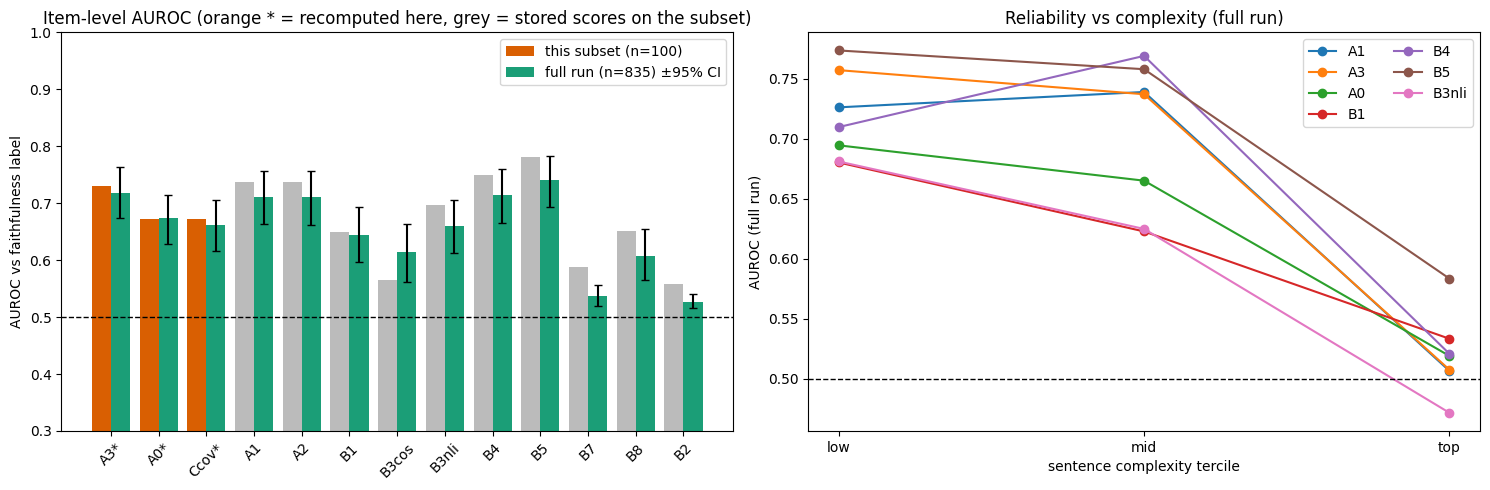

Pre-registered gates (full run): G1 coverage>=0.70, G2 rewrite false alarms<=0.10, G3 increment CI>0, G4 AUROC>=0.65
  A1: G1=0.86(ok)  G2=0.131(FAIL)  G3 dAUROC=0.084 CI=[0.037, 0.138](ok)  G4=0.711(ok)  survives=False  top-tercile AUROC=0.507
  A2: G1=0.86(ok)  G2=0.131(FAIL)  G3 dAUROC=0.084 CI=[0.036, 0.138](ok)  G4=0.711(ok)  survives=False  top-tercile AUROC=0.507
  A3: G1=0.88(ok)  G2=0.143(FAIL)  G3 dAUROC=0.093 CI=[0.048, 0.143](ok)  G4=0.718(ok)  survives=False  top-tercile AUROC=0.508
outcome: advance_without_survivor -> advances: A3 (no survivor; largest ΔAUROC point estimate 0.093 >= 0.03)


In [18]:
pm = data["full_run_per_metric"]
names = VARIANTS + [b for b in baselines if b not in VARIANTS]
sub_auc = {v: auroc(recomputed[v]) for v in VARIANTS}
sub_auc.update({b: a for b, a in sub_auc_stored.items() if b not in sub_auc})
full = [pm[n]["AUROC_real"] for n in names]
lo = [pm[n]["AUROC_real"] - pm[n]["CI95"][0] for n in names]
hi = [pm[n]["CI95"][1] - pm[n]["AUROC_real"] for n in names]

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
x = np.arange(len(names))
ax[0].bar(x - 0.2, [sub_auc[n] for n in names], 0.4, label=f"this subset (n={len(sub)})",
          color=["#d95f02" if n in VARIANTS else "#bbbbbb" for n in names])
ax[0].bar(x + 0.2, full, 0.4, yerr=[lo, hi], capsize=3, label="full run (n=835) ±95% CI", color="#1b9e77")
ax[0].axhline(0.5, ls="--", c="k", lw=1)
ax[0].set_xticks(x, [n + ("*" if n in VARIANTS else "") for n in names], rotation=45)
ax[0].set_ylim(0.3, 1.0); ax[0].set_ylabel("AUROC vs faithfulness label")
ax[0].set_title("Item-level AUROC (orange * = recomputed here, grey = stored scores on the subset)"); ax[0].legend(loc="upper right")

terc = ["low", "mid", "top"]
for n in ["A1", "A3", "A0", "B1", "B4", "B5", "B3nli"]:
    ax[1].plot(terc, [pm[n]["per_tercile"].get(t) for t in terc], marker="o", label=n)
ax[1].axhline(0.5, ls="--", c="k", lw=1)
ax[1].set_xlabel("sentence complexity tercile"); ax[1].set_ylabel("AUROC (full run)")
ax[1].set_title("Reliability vs complexity (full run)"); ax[1].legend(ncol=2)
plt.tight_layout(); plt.show()

v = data["full_run_verdict"]
print("Pre-registered gates (full run): G1 coverage>=0.70, G2 rewrite false alarms<=0.10, G3 increment CI>0, G4 AUROC>=0.65")
for m, g in v["gates"].items():
    print(f"  {m}: G1={g['G1']['value']:.2f}({'ok' if g['G1']['pass'] else 'FAIL'})  G2={g['G2']['value']:.3f}"
          f"({'ok' if g['G2']['pass'] else 'FAIL'})  G3 dAUROC={g['G3']['delta']:.3f} CI={[round(c, 3) for c in g['G3']['ci95']]}"
          f"({'ok' if g['G3']['pass'] else 'FAIL'})  G4={g['G4']['value']:.3f}({'ok' if g['G4']['pass'] else 'FAIL'})"
          f"  survives={g['survives']}  top-tercile AUROC={g['top_tercile_auroc']:.3f}")
print(f"outcome: {v['outcome']} -> advances: {v['winner']} ({v['reason']})")